# CoLA Data Sampling Walkthrough

One notebook that documents both preprocessing (Step 1) and clustering/export (Step 2) so you can sanity-check every stage without rerunning the heavy scripts.

## Pipeline at a Glance

1. **Preprocess evaluable languages** (`python data_prep/preprocess_evaluable_languages.py`)
   - Filter FineWeb-2 to the 108-language evaluable pool (Belebele/FLORES overlap, train split, valid family).
   - Merge `lang_resource_dataset.tsv` → High/Medium/Low buckets to balance sampling tiers.
   - Build one-hot (structural) + LLM (semantic) embeddings, compute deterministic t-SNE projections, cache all artifacts under `processed_artifacts/`.
2. **Cluster + export benchmark subsets** (`python data_prep/create_benchmark_samples.py`)
   - Load cached artifacts, run Silhouette analysis to pick sample sizes, run KMeans, order medoids, and save nested subsets under `onehot_benchmark_samples/` + `llm_benchmark_samples/`.
   - Export three tiers: (a) small = best silhouette peak (~10), (b) medium = silhouette-supported size closest to the geometric mean between small and the full pool (~√(10·190) ≈ 44–64), (c) full = every evaluable language (~190).
   - Write interactive t-SNE plots with medoids highlighted next to each CSV.

**Why this split?** Preprocessing is expensive (remote embeddings) but deterministic; caching keeps later experiments fast. Clustering depends on experiment-specific `k`, so it stays in the second step.

### Scientific reasoning (advantages / trade-offs)
- ✅ Reproducibility: cached embeddings/t-SNEs ensure downstream sampling is deterministic until raw data changes.
- ✅ Coverage-aware: filtering to evaluable languages keeps every subset measurable on Belebele/FLORES.
- ✅ Resource context: tier metadata + t-SNE plots surface imbalances early.
- ⚠️ t-SNE distortion: 2D projections preserve local neighborhoods but can warp global structure.
- ⚠️ Cache staleness: rerun preprocessing whenever FineWeb metadata or the embedding endpoint changes.
- ⚠️ Remote dependency: LLM embeddings require the `nomic-embed-text-v2-moe` endpoint.


In [ ]:
from pathlib import Path
import pandas as pd
import plotly.express as px

try:
    NOTEBOOK_DIR = Path(__file__).parent.resolve()
except NameError:
    NOTEBOOK_DIR = Path.cwd().resolve()

candidate_dirs = [
    NOTEBOOK_DIR / "processed_artifacts",
    NOTEBOOK_DIR / ".." / "processed_artifacts",
    NOTEBOOK_DIR / "data_prep" / "processed_artifacts",
    NOTEBOOK_DIR / ".." / "data_prep" / "processed_artifacts",
]
DATA_DIR = next((p.resolve() for p in candidate_dirs if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "processed_artifacts/ not found. Run preprocess_evaluable_languages.py first or set DATA_DIR manually."
    )

metadata = pd.read_csv(DATA_DIR / "filtered_languages.csv")
onehot_tsne = pd.read_csv(DATA_DIR / "onehot_tsne.csv")
llm_tsne = pd.read_csv(DATA_DIR / "llm_tsne.csv")

print(f"Loaded {len(metadata)} evaluable languages.")
metadata.head()

In [ ]:
print("Resource tier distribution:\n")
display(metadata["resource_category"].value_counts())

print("\nTop scripts:")
display(metadata["script"].value_counts().head(10))

print("\nTop families:")
display(metadata["family"].value_counts().head(10))

### Interactive t-SNE with medoids (after Step 2)
Use the cell below to render the Plotly HTML files generated after clustering.

## Inspect clustering outputs (Step 2)



In [ ]:
def show_tsne_with_medoids(folder):
    base_dir = Path(NOTEBOOK_DIR)
    htmls = sorted((base_dir / folder).glob('*_tsne.html'))
    if not htmls:
        print(f'No t-SNE HTML files found in {folder}. Run create_benchmark_samples.py first.')
        return
    import IPython
    for html_path in htmls:
        print(f'Displaying {html_path.name}')
        display(IPython.display.HTML(filename=str(html_path)))

show_tsne_with_medoids('onehot_benchmark_samples')
show_tsne_with_medoids('llm_benchmark_samples')


In [ ]:
def list_samples(folder):
    path = Path(folder)
    if not path.exists():
        print(f"{folder} missing (run create_benchmark_samples.py).")
        return []
    csvs = sorted(path.glob("*.csv"))
    for csv_path in csvs:
        print(f"- {csv_path.name}")
    return csvs

print("One-hot samples:")
onehot_files = list_samples(Path(NOTEBOOK_DIR) / "onehot_benchmark_samples")
print("\nLLM samples:")
llm_files = list_samples(Path(NOTEBOOK_DIR) / "llm_benchmark_samples")
print("\nCoLA-optimal samples:")
cola_files = list_samples(Path(NOTEBOOK_DIR) / "cola_optimal_samples")

In [ ]:
def preview_csv(path_list, title):
    if not path_list:
        print(f"No files to preview for {title}.")
        return
    df = pd.read_csv(path_list[0])
    print(f"Previewing {path_list[0].name} ({len(df)} rows)")
    display(df.head())

preview_csv(onehot_files, "one-hot")
preview_csv(llm_files, "llm")
preview_csv(cola_files, "CoLA")

## Interpreting the samples

- **Nested medoids** (`*_representative_mediods.csv`): each file contains the first *k* medoids ordered via farthest-first traversal, so larger tiers strictly superset smaller ones.
- The interactive Plotly HTMLs generated during Step 2 (e.g., `llm_k40_tsne.html`) include medoid markers and hover tooltips mirroring `fineweb2_medoid_clustering.py`; open them in a browser for spatial intuition.
- The largest tier in each embedding family always equals the total number of evaluable languages, ensuring you can grab the full ~190-lang list without extra bookkeeping.


### Characterizing the small-tier subset
- Size = top silhouette peak (≈10). It captures the most cohesive language grouping detected across the one-hot/LLM embeddings.
- Use cases: quick smoke tests, router/adapter sanity checks, ablations where budget constraints limit language count.
- Composition: because the subset is derived from KMeans medoids, it spans diverse families within the most tightly clustered region, making it a high-quality representative seed.


## Step 3: Advanced Selection (User Request)

1. Find optimal cluster count (Silhouette).
2. Select 4 most distinct clusters (>= 12 languages).
3. Sample 12 languages from each (Medoid + Farthest Point Sampling).

Loaded embeddings: (191, 2048)
Running Silhouette Analysis...


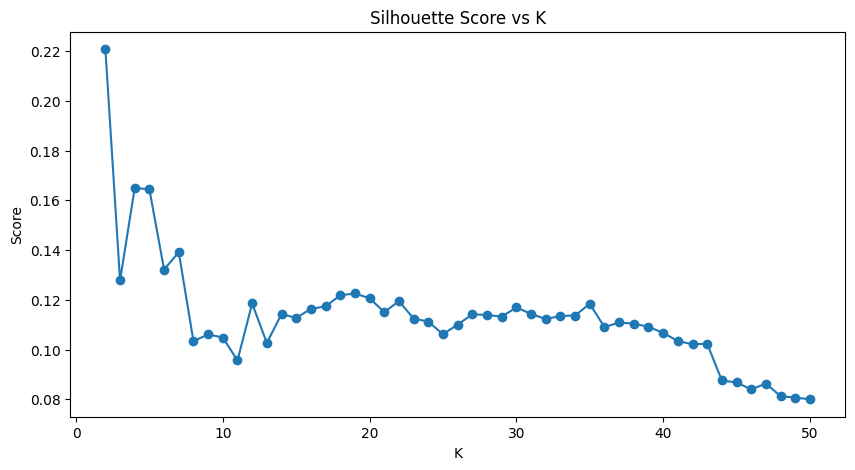

[(2, 0.22072092349833505), (3, 0.12777296176606726), (4, 0.16498132034776541), (5, 0.1643487452149316), (6, 0.132148486935664), (7, 0.13910531426537923), (8, 0.10336658458404396), (9, 0.10607384552435253), (10, 0.10482071457650946), (11, 0.09561117901431036), (12, 0.11852224108132571), (13, 0.10260387433136055), (14, 0.11428694696350372), (15, 0.11266784355775053), (16, 0.11635362726161445), (17, 0.11732450724103828), (18, 0.12180396575570357), (19, 0.122527181531303), (20, 0.12062015625562926), (21, 0.11503419347238979), (22, 0.11945377720307593), (23, 0.11244516373386677), (24, 0.11123702120856463), (25, 0.10609024473123026), (26, 0.11003363061398748), (27, 0.11414282369821158), (28, 0.11392174057628786), (29, 0.11321979551211193), (30, 0.11690615616905373), (31, 0.11434495799782808), (32, 0.11224486249021694), (33, 0.11349746748817138), (34, 0.11365614103607428), (35, 0.11838741678149813), (36, 0.10900319991706701), (37, 0.11086904954951754), (38, 0.11038521557634191), (39, 0.109136

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances
import matplotlib.pyplot as plt

# Load Llama-3 embeddings
emb_df = pd.read_csv(DATA_DIR / "llm_embeddings.csv")
X = emb_df.values
print(f"Loaded embeddings: {X.shape}")

# 1. Silhouette Analysis
scores = []
K_range = range(2, 51)
print("Running Silhouette Analysis...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

optimal_k = K_range[np.argmax(scores)]
print("All silhouette scores:", list(zip(K_range, scores)))
top5 = sorted(zip(K_range, scores), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 silhouette scores:", top5)
print(f"Optimal K based on max silhouette: {optimal_k}")

In [39]:
# 2. Cluster & Select Distinct/Dense Clusters
from sklearn.metrics import silhouette_samples

# User requested manual control or K=4/5 based on the plot.
# We'll set a default of 4, but you can change this.
MANUAL_K = 4

if MANUAL_K:
    print(f"Using Manual K = {MANUAL_K}")
    optimal_k = MANUAL_K
elif optimal_k < 4:
    print(f"Optimal K ({optimal_k}) is too small for 4 distinct clusters. Forcing K=8.")
    optimal_k = 8

kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init="auto", random_state=42)
labels = kmeans.fit_predict(X)
metadata["cluster_id"] = labels

# Compute per-sample silhouette scores to find "dense" clusters
sil_samples = silhouette_samples(X, labels)
metadata["silhouette"] = sil_samples

cluster_stats = []
for k in range(optimal_k):
    members = metadata[metadata["cluster_id"] == k]
    if len(members) >= 12:
        # "Density" proxy: average silhouette score of cluster members
        avg_sil = members["silhouette"].mean()
        cluster_stats.append({
            "cluster_id": k,
            "size": len(members),
            "density": avg_sil
        })

# Sort by density (descending) to pick the most cohesive clusters
cluster_stats.sort(key=lambda x: x["density"], reverse=True)
top_4_clusters = cluster_stats[:4]

print("Selected Clusters (Top 4 Dense with >= 12 langs):")
for c in top_4_clusters:
    print(f"ID: {c['cluster_id']}, Size: {c['size']}, Avg Silhouette (Density): {c['density']:.4f}")

if len(top_4_clusters) < 4:
    print("WARNING: Found fewer than 4 clusters with >= 12 languages!")

Using Manual K = 4
Selected Clusters (Top 4 Dense with >= 12 langs):
ID: 1, Size: 60, Avg Silhouette (Density): 0.2204
ID: 2, Size: 79, Avg Silhouette (Density): 0.1465
ID: 0, Size: 47, Avg Silhouette (Density): 0.1246


In [40]:
# 3. Sample 12 Languages per Cluster

selected_indices = []

def farthest_point_sampling(indices, embeddings, n_samples):
    # Start with medoid (closest to cluster center)
    center = embeddings[indices].mean(axis=0)
    dists = pairwise_distances(embeddings[indices], center.reshape(1, -1)).flatten()
    medoid_rel_idx = np.argmin(dists)
    medoid_idx = indices[medoid_rel_idx]
    
    selected = [medoid_idx]
    
    while len(selected) < n_samples:
        remaining = list(set(indices) - set(selected))
        if not remaining:
            break
            
        # For each remaining point, find distance to nearest selected point
        # We want the point where this 'min distance' is maximized
        
        # Compute distances from all remaining to all selected
        rem_emb = embeddings[remaining]
        sel_emb = embeddings[selected]
        
        dists_to_selected = pairwise_distances(rem_emb, sel_emb)
        min_dists = dists_to_selected.min(axis=1)
        
        next_rel_idx = np.argmax(min_dists)
        next_idx = remaining[next_rel_idx]
        selected.append(next_idx)
        
    return selected

for c in top_4_clusters:
    cid = c["cluster_id"]
    indices = metadata[metadata["cluster_id"] == cid].index.tolist()
    selected = farthest_point_sampling(indices, X, 12)
    selected_indices.extend(selected)

final_df = metadata.loc[selected_indices].copy()
final_df.to_csv("selected_4x12_languages.csv", index=False)
print(f"Saved {len(final_df)} languages to selected_4x12_languages.csv")
final_df.head()

Saved 36 languages to selected_4x12_languages.csv


,subset,split,code,script,name,family,words,documents,utf8_bytes,utf8_bytes_human,...,parquet_bytes_human,bible_ratio,wiki_ratio,resource_category,cluster_id,TSNE1,TSNE2,selected,selected_int,silhouette
140,kik_Latn,train,kik,Latn,Kikuyu,Niger-Congo,722464,7292,4384691,4.18MB,...,2.12MB,0.000,0.002,low,1,-7.177917,9.274784,False,0,0.380613
23,tha_Thai,train,tha,Thai,Thai,Kra-Dai,24662748945,35897202,299226473998,278.68GB,...,69.91GB,-,-,high,1,-10.292398,2.766330,True,1,0.037482
182,taq_Latn,train,taq,Latn,Tamasheq,Afro-Asiatic,573379,442,2516396,2.40MB,...,969.92KB,0.839,0.000,low,1,-11.522358,8.880234,True,1,0.187073
153,ayr_Latn,train,ayr,Latn,Central Aymara,Aymaran,1705732,3395,11492144,10.96MB,...,4.84MB,0.039,0.205,low,1,-10.675842,6.970047,True,1,0.225383
128,shn_Mymr,train,shn,Mymr,Shan,Kra-Dai,3981060,19218,126345158,120.49MB,...,23.15MB,0.013,0.494,low,1,-0.741925,7.533958,False,0,0.097030


In [ ]:
# 4. Visualize Selection (Rich Interactive Plot: t-SNE + UMAP)
import plotly.graph_objects as go
from sklearn.manifold import TSNE

# Try importing UMAP, install if missing
try:
    import umap
except ImportError:
    print("UMAP not found. Installing umap-learn...")
    !pip install umap-learn
    import umap

def create_hover_template(projection_name="TSNE"):
    return "<b>%{hovertext}</b><br>" + \
           f"{projection_name}1: %{{customdata[0]:.3f}}<br>" + \
           f"{projection_name}2: %{{customdata[1]:.3f}}<br>" + \
           "Cluster: %{customdata[2]}<br>" + \
           "Family: %{customdata[3]}<br>" + \
           "Resource: %{customdata[4]}<br>" + \
           "Selected: %{customdata[5]}<br>" + \
           "<extra></extra>"

# --- t-SNE ---
print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)
metadata["TSNE1"] = X_tsne[:, 0]
metadata["TSNE2"] = X_tsne[:, 1]

# --- UMAP ---
print("Computing UMAP...")
try:
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X)
    metadata["UMAP1"] = X_umap[:, 0]
    metadata["UMAP2"] = X_umap[:, 1]
except Exception as e:
    print(f"UMAP failed: {e}")
    metadata["UMAP1"] = 0.0
    metadata["UMAP2"] = 0.0

metadata["selected"] = metadata.index.isin(selected_indices)
metadata["selected_int"] = metadata["selected"].astype(int)

def plot_projection(projection_name, x_col, y_col):
    fig = go.Figure()

    # Add all points (colored by cluster)
    fig.add_trace(go.Scatter(
        x=metadata[x_col],
        y=metadata[y_col],
        mode='markers',
        marker=dict(
            size=8,
            color=metadata["cluster_id"],
            colorscale='Viridis',
            opacity=0.6,
            showscale=False
        ),
        text=metadata["name"],
        customdata=metadata[[x_col, y_col, "cluster_id", "family", "resource_category", "selected"]],
        hovertemplate=create_hover_template(projection_name),
        name='All Languages'
    ))

    # Add selected points (Medoids/Representatives) as a separate, highlighted trace
    selected_df = metadata[metadata["selected"]]
    fig.add_trace(go.Scatter(
        x=selected_df[x_col],
        y=selected_df[y_col],
        mode='markers',
        marker=dict(
            size=14,
            color='red',
            symbol='circle',
            line=dict(width=2, color='darkred')
        ),
        text=selected_df["name"],
        customdata=selected_df[[x_col, y_col, "cluster_id", "family", "resource_category", "selected"]],
        hovertemplate=create_hover_template(projection_name),
        name='Selected (12/cluster)'
    ))

    fig.update_layout(
        title=f"Selected 4x12 Languages (K={optimal_k}) - {projection_name}<br>Red circles = Selected Representatives",
        width=1200,
        height=800,
        legend_title="Legend",
        hoverlabel=dict(bgcolor="white", font_size=12)
    )
    fig.show()

plot_projection("t-SNE", "TSNE1", "TSNE2")
if "UMAP1" in metadata.columns:
    plot_projection("UMAP", "UMAP1", "UMAP2")


In [ ]:
# 5. Comparison: HDBSCAN Clustering
# HDBSCAN is a density-based clustering algorithm that doesn't require specifying K.
# It identifies 'noise' points (label -1) and can find clusters of varying densities.

# Try importing hdbscan, install if missing
try:
    import hdbscan
except ImportError:
    print("HDBSCAN not found. Installing hdbscan...")
    !pip install hdbscan
    import hdbscan

print("Running HDBSCAN...")
# min_cluster_size: smallest size grouping that you wish to consider a cluster
# min_samples: measure of how conservative you want the clustering to be (larger = more noise)
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, gen_min_span_tree=True)
hdbscan_labels = clusterer.fit_predict(X)
metadata["hdbscan_cluster"] = hdbscan_labels

n_clusters_hdbscan = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = list(hdbscan_labels).count(-1)
print(f"HDBSCAN found {n_clusters_hdbscan} clusters and {n_noise} noise points.")

# Visualize HDBSCAN on UMAP
if "UMAP1" in metadata.columns:
    fig = go.Figure()

    # Add all points (colored by HDBSCAN cluster)
    # We handle noise (-1) separately or let it be part of the colorscale
    fig.add_trace(go.Scatter(
        x=metadata["UMAP1"],
        y=metadata["UMAP2"],
        mode='markers',
        marker=dict(
            size=8,
            color=metadata["hdbscan_cluster"],
            colorscale='Turbo',
            opacity=0.6,
            showscale=False
        ),
        text=metadata["name"],
        customdata=metadata[["UMAP1", "UMAP2", "hdbscan_cluster", "family", "resource_category"]],
        hovertemplate="<b>%{hovertext}</b><br>" + \
                      "UMAP1: %{customdata[0]:.3f}<br>" + \
                      "UMAP2: %{customdata[1]:.3f}<br>" + \
                      "HDBSCAN Cluster: %{customdata[2]}<br>" + \
                      "Family: %{customdata[3]}<br>" + \
                      "Resource: %{customdata[4]}<br>" + \
                      "<extra></extra>",
        name='HDBSCAN Clusters'
    ))

    fig.update_layout(
        title=f"HDBSCAN Clustering on UMAP Projection<br>Found {n_clusters_hdbscan} clusters, {n_noise} noise points",
        width=1200,
        height=800,
        legend_title="Legend",
        hoverlabel=dict(bgcolor="white", font_size=12)
    )
    fig.show()
else:
    print("UMAP projection not found. Run the previous cell first.")


In [ ]:
# 6. Refined Clustering Pipeline (PCA + HDBSCAN + Hierarchical)
# As per best practices: Reduce dims -> Cluster -> Visualize

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import homogeneity_score

# 1. PCA Reduction
print("Running PCA (reducing to 50 dims)...")
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X)
print(f"Explained Variance Ratio (First 50 components): {sum(pca.explained_variance_ratio_):.4f}")

# 2. HDBSCAN on PCA Data
print("Running HDBSCAN on PCA data...")
try:
    import hdbscan
    clusterer_pca = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5, gen_min_span_tree=True)
    hdbscan_pca_labels = clusterer_pca.fit_predict(X_pca)
    metadata["hdbscan_pca_cluster"] = hdbscan_pca_labels
    
    n_clusters_pca = len(set(hdbscan_pca_labels)) - (1 if -1 in hdbscan_pca_labels else 0)
    n_noise_pca = list(hdbscan_pca_labels).count(-1)
    print(f"HDBSCAN (PCA) found {n_clusters_pca} clusters and {n_noise_pca} noise points.")
except ImportError:
    print("HDBSCAN not installed.")

# 3. Hierarchical Clustering (Cosine) + Dendrogram
print("Running Hierarchical Clustering (Cosine)...")
# We use scipy's linkage for the dendrogram
Z = linkage(X_pca, method='ward') # Ward minimizes variance, often good for structure
# Note: For pure cosine distance, we might prefer method='average' or 'complete' with metric='cosine',
# but Ward is standard on Euclidean. Since X_pca is Euclidean space approximation, Ward is okay.
# Alternatively, we can normalize X_pca and use Euclidean to approx Cosine.

plt.figure(figsize=(15, 7))
plt.title("Hierarchical Clustering Dendrogram (Ward on PCA)")
dendrogram(Z, labels=metadata.index, leaf_rotation=90., leaf_font_size=8.)
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

# 4. Evaluation against Language Families
print("\n--- Cluster Evaluation (Homogeneity vs Family) ---")
if "family" in metadata.columns:
    # K-Means (Original)
    if "cluster_id" in metadata.columns:
        score_kmeans = homogeneity_score(metadata["family"], metadata["cluster_id"])
        print(f"K-Means Homogeneity: {score_kmeans:.4f}")
    
    # HDBSCAN (Original)
    if "hdbscan_cluster" in metadata.columns:
        # Filter out noise for fair comparison?
        mask = metadata["hdbscan_cluster"] != -1
        if mask.sum() > 0:
            score_hdbscan = homogeneity_score(metadata.loc[mask, "family"], metadata.loc[mask, "hdbscan_cluster"])
            print(f"HDBSCAN (Original) Homogeneity (excl. noise): {score_hdbscan:.4f}")
            
    # HDBSCAN (PCA)
    if "hdbscan_pca_cluster" in metadata.columns:
        mask = metadata["hdbscan_pca_cluster"] != -1
        if mask.sum() > 0:
            score_hdbscan_pca = homogeneity_score(metadata.loc[mask, "family"], metadata.loc[mask, "hdbscan_pca_cluster"])
            print(f"HDBSCAN (PCA) Homogeneity (excl. noise): {score_hdbscan_pca:.4f}")

# Visualize HDBSCAN (PCA) on UMAP
if "UMAP1" in metadata.columns and "hdbscan_pca_cluster" in metadata.columns:
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=metadata["UMAP1"],
        y=metadata["UMAP2"],
        mode='markers',
        marker=dict(
            size=8,
            color=metadata["hdbscan_pca_cluster"],
            colorscale='Turbo',
            opacity=0.6,
            showscale=False
        ),
        text=metadata["name"],
        customdata=metadata[["UMAP1", "UMAP2", "hdbscan_pca_cluster", "family", "resource_category"]],
        hovertemplate="<b>%{hovertext}</b><br>" + \
                      "UMAP1: %{customdata[0]:.3f}<br>" + \
                      "UMAP2: %{customdata[1]:.3f}<br>" + \
                      "HDBSCAN(PCA) Cluster: %{customdata[2]}<br>" + \
                      "Family: %{customdata[3]}<br>" + \
                      "Resource: %{customdata[4]}<br>" + \
                      "<extra></extra>",
        name='HDBSCAN (PCA) Clusters'
    ))
    fig.update_layout(
        title=f"HDBSCAN (PCA) Clustering on UMAP Projection<br>Found {n_clusters_pca} clusters",
        width=1200,
        height=800,
        legend_title="Legend",
        hoverlabel=dict(bgcolor="white", font_size=12)
    )
    fig.show()


In [ ]:
# 7. Advanced Evaluation: Metrics & Local Consistency
from sklearn.metrics import adjusted_mutual_info_score, normalized_mutual_info_score, adjusted_rand_score
from scipy.cluster.hierarchy import fcluster

print("\n--- Advanced Cluster Evaluation ---")

# 1. Pairwise Distance Analysis (Nearest Neighbors)
# Do languages find their siblings? (Local Consistency)
print("\n1. Nearest Neighbor Analysis (Local Consistency):")
if "family" in metadata.columns:
    # Compute pairwise distances on PCA data (or original)
    dists = pairwise_distances(X_pca)
    np.fill_diagonal(dists, np.inf) # Ignore self
    
    correct_family_matches = 0
    total_eval = 0
    
    for i in range(len(metadata)):
        # Find index of nearest neighbor
        nn_idx = np.argmin(dists[i])
        
        lang_family = metadata.iloc[i]["family"]
        nn_family = metadata.iloc[nn_idx]["family"]
        
        # Ignore 'Language isolate' or 'Constructed language' for strict evaluation?
        # Let's keep them for now, but they might be noise.
        if lang_family == nn_family:
            correct_family_matches += 1
        total_eval += 1
            
    accuracy = correct_family_matches / total_eval
    print(f"Nearest Neighbor Family Match Accuracy: {accuracy:.4f} ({correct_family_matches}/{total_eval})")
    print("Interpretation: Probability that the closest language in embedding space belongs to the same family.")

# 2. Clustering Metrics (AMI, NMI, ARI)
print("\n2. Global Clustering Metrics (Ground Truth = Family):")
def print_metrics(name, labels, true_labels):
    # Filter out noise (-1) for HDBSCAN fairness if needed, or treat as own cluster
    # Standard practice: treat noise as a single cluster or exclude. Let's exclude for 'purity' check.
    mask = labels != -1
    if mask.sum() < 2:
        print(f"{name}: Not enough data (mostly noise)")
        return
        
    l_pred = labels[mask]
    l_true = true_labels[mask]
    
    ami = adjusted_mutual_info_score(l_true, l_pred)
    nmi = normalized_mutual_info_score(l_true, l_pred)
    ari = adjusted_rand_score(l_true, l_pred)
    print(f"{name:20s} | AMI: {ami:.4f} | NMI: {nmi:.4f} | ARI: {ari:.4f}")

if "family" in metadata.columns:
    # K-Means
    if "cluster_id" in metadata.columns:
        print_metrics("K-Means", metadata["cluster_id"].values, metadata["family"].values)
    
    # HDBSCAN (Original)
    if "hdbscan_cluster" in metadata.columns:
        print_metrics("HDBSCAN (Orig)", metadata["hdbscan_cluster"].values, metadata["family"].values)
        
    # HDBSCAN (PCA)
    if "hdbscan_pca_cluster" in metadata.columns:
        print_metrics("HDBSCAN (PCA)", metadata["hdbscan_pca_cluster"].values, metadata["family"].values)

# 3. Hierarchical Cuts Analysis
print("\n3. Hierarchical Cuts Analysis:")
# Evaluate clustering at different granularities (number of clusters)
cut_results = []
k_candidates = [5, 10, 20, 30, 40, 50, 60]

print(f"{'K':<5} | {'AMI':<8} | {'NMI':<8} | {'ARI':<8}")
print("-"*35)

for k in k_candidates:
    # fcluster with criterion='maxclust' lets us specify k
    labels_cut = fcluster(Z, t=k, criterion='maxclust')
    
    ami = adjusted_mutual_info_score(metadata["family"], labels_cut)
    nmi = normalized_mutual_info_score(metadata["family"], labels_cut)
    ari = adjusted_rand_score(metadata["family"], labels_cut)
    
    print(f"{k:<5} | {ami:.4f}   | {nmi:.4f}   | {ari:.4f}")
    cut_results.append((k, ami, nmi, ari))

print("\nCheck which K maximizes AMI/NMI to find the 'natural' granularity of families in this space.")


In [ ]:
# 8. Final Polish & Robustness
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n--- Final Polish & Robustness ---")

# 1. Conservative HDBSCAN Scoring (Noise as Cluster)
print("\n1. Conservative HDBSCAN Scoring (Treating Noise as a Distinct Cluster):")
if "hdbscan_cluster" in metadata.columns and "family" in metadata.columns:
    # Create a copy of labels where noise (-1) is mapped to a unique positive integer
    # so it's treated as a valid cluster for scoring, rather than ignored.
    # Actually, sklearn metrics handle -1 as a cluster label if we don't exclude it.
    # But usually -1 means "no cluster". Let's treat all -1s as belonging to a "Noise Cluster".
    
    labels_cons = metadata["hdbscan_cluster"].copy()
    # Map -1 to a new cluster ID (max + 1)
    noise_id = labels_cons.max() + 1
    labels_cons[labels_cons == -1] = noise_id
    
    ami = adjusted_mutual_info_score(metadata["family"], labels_cons)
    nmi = normalized_mutual_info_score(metadata["family"], labels_cons)
    ari = adjusted_rand_score(metadata["family"], labels_cons)
    print(f"HDBSCAN (Orig, Conservative) | AMI: {ami:.4f} | NMI: {nmi:.4f} | ARI: {ari:.4f}")

# 2. Tuned HDBSCAN on PCA (Cosine Metric)
print("\n2. Tuned HDBSCAN on PCA (Cosine Metric):")
try:
    import hdbscan
    # Metric='indefinite' is sometimes needed for cosine in hdbscan if data isn't normalized,
    # but usually 'euclidean' on normalized data is equivalent to cosine.
    # Let's normalize X_pca first, then use euclidean (standard trick).
    from sklearn.preprocessing import normalize
    X_pca_norm = normalize(X_pca)
    
    # Lower min_samples to capture density better in sparse high-dim space
    clusterer_tuned = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2, metric='euclidean', gen_min_span_tree=True)
    labels_tuned = clusterer_tuned.fit_predict(X_pca_norm)
    metadata["hdbscan_tuned"] = labels_tuned
    
    n_clusters_tuned = len(set(labels_tuned)) - (1 if -1 in labels_tuned else 0)
    n_noise_tuned = list(labels_tuned).count(-1)
    print(f"Tuned HDBSCAN found {n_clusters_tuned} clusters and {n_noise_tuned} noise points.")
    
    # Score it (Conservative)
    labels_tuned_cons = labels_tuned.copy()
    labels_tuned_cons[labels_tuned_cons == -1] = labels_tuned_cons.max() + 1
    ami = adjusted_mutual_info_score(metadata["family"], labels_tuned_cons)
    print(f"Tuned HDBSCAN (Conservative) | AMI: {ami:.4f}")
except ImportError:
    print("HDBSCAN not installed.")

# 3. Family Confusion Matrix (Heatmap)
print("\n3. Family Confusion Matrix (Nearest Neighbor):")
if "family" in metadata.columns:
    # We use the Nearest Neighbor analysis from before to build a confusion matrix
    # True Label = Language Family
    # Predicted Label = Family of Nearest Neighbor
    
    dists = pairwise_distances(X_pca)
    np.fill_diagonal(dists, np.inf)
    
    y_true = []
    y_pred = []
    
    for i in range(len(metadata)):
        nn_idx = np.argmin(dists[i])
        y_true.append(metadata.iloc[i]["family"])
        y_pred.append(metadata.iloc[nn_idx]["family"])
        
    # Filter to top N families to keep heatmap readable
    top_families = metadata["family"].value_counts().head(15).index
    mask = [t in top_families and p in top_families for t, p in zip(y_true, y_pred)]
    y_true_filt = [t for i, t in enumerate(y_true) if mask[i]]
    y_pred_filt = [p for i, p in enumerate(y_pred) if mask[i]]
    
    labels = sorted(list(set(y_true_filt)))
    cm = confusion_matrix(y_true_filt, y_pred_filt, labels=labels, normalize='true')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title("Family Confusion Matrix (Top 15 Families)\nRow: True Family, Col: Nearest Neighbor Family")
    plt.ylabel("True Family")
    plt.xlabel("Nearest Neighbor Family")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    print("Diagonal = Self-consistency. Off-diagonal = Frequent confusions (e.g., Turkic <-> Mongolic).")


In [51]:
# 4. Visualize Tuned HDBSCAN Clusters & Noise
print("\n4. Visualizing Tuned HDBSCAN Clusters (Noise in Grey):")
if "UMAP1" in metadata.columns and "hdbscan_tuned" in metadata.columns:
    fig = go.Figure()
    
    # Separate noise and clusters
    noise_mask = metadata["hdbscan_tuned"] == -1
    cluster_mask = ~noise_mask
    
    # 1. Plot Noise (Grey, smaller, lower opacity)
    if noise_mask.sum() > 0:
        fig.add_trace(go.Scatter(
            x=metadata.loc[noise_mask, "UMAP1"],
            y=metadata.loc[noise_mask, "UMAP2"],
            mode='markers',
            marker=dict(
                size=6,
                color='lightgrey',
                opacity=0.4,
                line=dict(width=0)
            ),
            text=metadata.loc[noise_mask, "name"],
            customdata=metadata.loc[noise_mask, ["UMAP1", "UMAP2", "hdbscan_tuned", "family", "resource_category"]],
            hovertemplate="<b>%{hovertext}</b> (Noise)<br>" + \
                          "UMAP1: %{customdata[0]:.3f}<br>" + \
                          "UMAP2: %{customdata[1]:.3f}<br>" + \
                          "Family: %{customdata[3]}<br>" + \
                          "<extra></extra>",
            name='Noise Points'
        ))
        
    # 2. Plot Clusters (Colored by Cluster ID)
    if cluster_mask.sum() > 0:
        fig.add_trace(go.Scatter(
            x=metadata.loc[cluster_mask, "UMAP1"],
            y=metadata.loc[cluster_mask, "UMAP2"],
            mode='markers',
            marker=dict(
                size=9,
                color=metadata.loc[cluster_mask, "hdbscan_tuned"],
                colorscale='Turbo',
                opacity=0.8,
                line=dict(width=1, color='DarkSlateGrey'),
                showscale=False
            ),
            text=metadata.loc[cluster_mask, "name"],
            customdata=metadata.loc[cluster_mask, ["UMAP1", "UMAP2", "hdbscan_tuned", "family", "resource_category"]],
            hovertemplate="<b>%{hovertext}</b><br>" + \
                          "Cluster ID: %{customdata[2]}<br>" + \
                          "Family: %{customdata[3]}<br>" + \
                          "Resource: %{customdata[4]}<br>" + \
                          "<extra></extra>",
            name='Clustered Languages'
        ))

    fig.update_layout(
        title=f"Tuned HDBSCAN Clusters on UMAP<br>Noise points in grey",
        width=1200,
        height=800,
        legend_title="Legend",
        hoverlabel=dict(bgcolor="white", font_size=12),
        template="plotly_white"
    )
    fig.show()



4. Visualizing Tuned HDBSCAN Clusters (Noise in Grey):
